In [2]:
%matplotlib widget

In [3]:
import matplotlib.pyplot as plot
import numpy as num
import ipywidgets as wids
from IPython.display import display
from matplotlib.animation import FuncAnimation

Output()

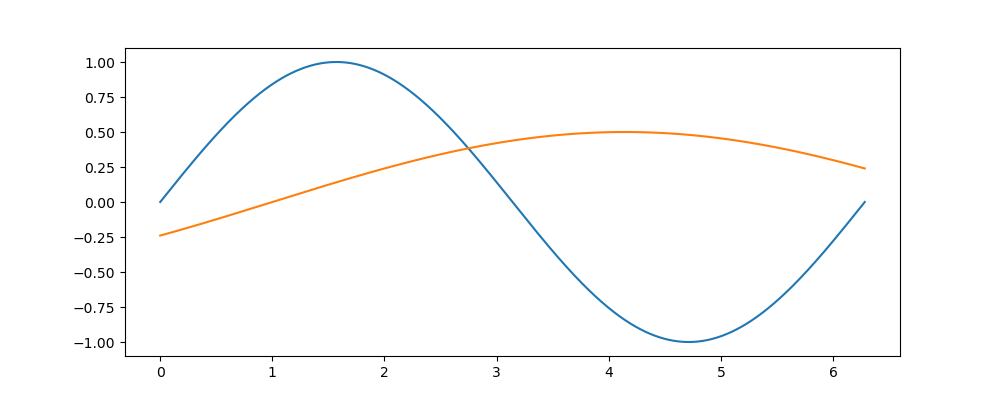

In [4]:
xs = num.linspace(0, 2*num.pi, 1000)
ys = num.sin(xs) * 1
y2 = num.sin(xs+ num.pi/2) * 1

fig, ax = plot.subplots(figsize = (10, 4))
line1, = ax.plot(xs, ys)
line2, = ax.plot(xs, y2)

def update_plot(a, f, t):
    y2 = a * num.sin(f * xs - t)
    line2.set_ydata(y2)
    fig.canvas.draw_idle()

def update_wave(i, a, f, line2):
    t = xs[i]
    y2 = a * num.sin(f * xs - t)
    line2.set_ydata(y2)
    return line2

def create_animation():
    return FuncAnimation(fig, update_wave, fargs=(a_slider, f_slider, line2), frames=len(xs), interval=1, repeat=True)

a_slider = wids.FloatSlider(value=0.5, min=0.5, max=3.0, description='Amplitude')
f_slider = wids.FloatSlider(value=0.5, min=0.5, max=3.0, description='Frequency')
t_slider = wids.FloatSlider(value=0.5, min=0.0, max=60.0, description='Displacement')
out = wids.interactive_output(update_plot, {'a': a_slider, 'f': f_slider, 't': t_slider})
ctrls = wids.VBox([a_slider, f_slider, t_slider])
animation = create_animation()
display(ctrls, out)
plot.show()

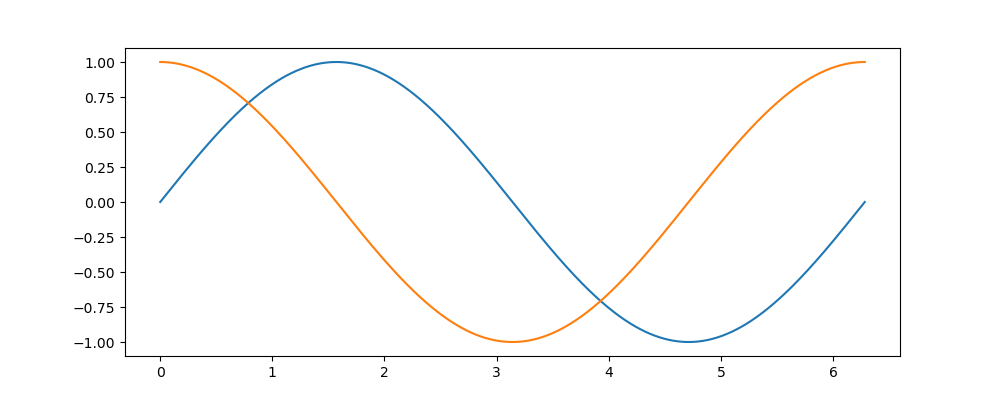

In [5]:
xs = num.linspace(0, 2*num.pi, 1000)
ys = num.sin(xs) * 1
y2 = num.sin(xs+ num.pi/2) * 1

def update_wave(i, line2):
    t = xs[i]
    print(t)
    y2 = num.sin(xs - t)
    line2.set_ydata(y2)
    return line2

def create_animation():
    fig, ax = plot.subplots(figsize = (10, 4))
    line1, = ax.plot(xs, ys)
    line2, = ax.plot(xs, y2)
    anim = FuncAnimation(fig, update_wave, fargs=(line2,), frames=len(xs), interval=5, repeat=True)
    return anim

anim = create_animation()

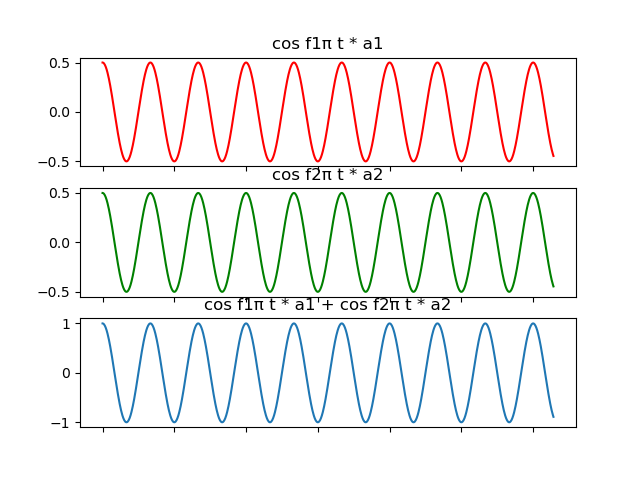

In [6]:
a1_slider = wids.FloatSlider(value=0.5, min=0.5, max=3.0, description='a1')
f1_slider = wids.FloatSlider(value=6.0, min=6.0, max=12.0, description='f1', step=0.5)
a2_slider = wids.FloatSlider(value=0.5, min=0.5, max=3.0, description='a2')
f2_slider = wids.FloatSlider(value=6.0, min=6.0, max=12.0, description='f2', step=0.5)
a1, f1, a2, f2 = a1_slider.value, f1_slider.value, a2_slider.value, f2_slider.value
fig, (ax1, ax2, ax3) = plot.subplots(nrows=3, ncols=1)
xs = num.linspace(0, 1 * num.pi, 1000)
y1 = num.cos(xs * f1 * num.pi) * a1
y2 = num.cos(xs * f2 * num.pi) * a2
y3 = y1 + y2
line1, = ax1.plot(xs, y1, color='red')
line2, = ax2.plot(xs, y2, color='green')
line3, = ax3.plot(xs, y3)
ax1.set_title('cos f1π t * a1')
ax2.set_title('cos f2π t * a2')
ax3.set_title('cos f1π t * a1 + cos f2π t * a2')
ax1.set_xticklabels('')
ax2.set_xticklabels('')
ax3.set_xticklabels('')
ctrls = wids.VBox([a1_slider, f1_slider, a2_slider, f2_slider])
display(ctrls)

def update_wave(i, line1, line2, line3):
    a1, f1, a2, f2 = a1_slider.value, f1_slider.value, a2_slider.value, f2_slider.value
    y1 = num.cos(xs * f1 * num.pi - i) * a1
    y2 = num.cos(xs * f2 * num.pi - i) * a2
    y3 = y1 + y2
    line1.set_ydata(y1)
    line2.set_ydata(y2)
    line3.set_ydata(y3)
    return line1, line2, line3

anim = FuncAnimation(fig, update_wave, fargs=(line1, line2, line3), frames=len(xs), interval=5, repeat=True)
plot.show()